# Curated biological Boolean network models

In this tutorial, we study how to analyze curated biological Boolean networks.

You will learn how to:

- load repositories of curated biological Boolean network models,
- analyze these models,
- generate null models to test the statistical significance of features in biological models.

These tools enable real research findings, namely the identification of 
design principles of regulatory functions and networks.

## Setup

In [1]:
import boolforge
import numpy as np
import matplotlib.pyplot as plt

## Loading model repositories
BoolForge makes it very easy to load all models included in three different 
repositories of curated biological Boolean networks.

In [2]:
models = boolforge.get_bio_models_from_repository()
bns = models['BooleanNetworks']
n_models = len(bns)

The function `get_bio_models_from_repository` loads, by default, all 122 distinct 
biological Boolean network models, analyzed in 
[Kadelka et al., Sci Adv, 2024](https://www.science.org/doi/full/10.1126/sciadv.adj0822),
and deposited in a [Github repository](https://github.com/ckadelka/DesignPrinciplesGeneNetworks).
The models are parsed directly from the associated Github repository, meaning
a wireless connection is required to successfully execute this function.

Models from the two other available repositories can be loaded by selecting the 
respective Github repository name:

- ['pystablemotifs (jcrozum)'](https://github.com/jcrozum/pystablemotifs)
- ['biodivine (sybila)'](https://github.com/sybila/biodivine-boolean-models)

In [3]:
models_sm = boolforge.get_bio_models_from_repository('pystablemotifs (jcrozum)')
bns_sm = models_sm['BooleanNetworks']
n_models_sm = len(bns_sm)

#models_bd = boolforge.get_bio_models_from_repository('biodivine (sybila)')
#n_models_bd = len(models_bd)
#bns_bd = models_bd['BooleanNetworks']

Note that the last repository is very large, which is why this code is commented out.

## Analyzing model repositories
By applying BoolForge functions to all models in a repository, we can swiftly
generate summary statistics, such as the size distribution of the models, or their average degree.

In [4]:
sizes = [bn.N for bn in bns]
average_degrees = [np.mean(bn.indegrees) for bn in bns]

Plotting the size of a model against its average degree, we observe that,
for these models, there exists no strong correlation between size and degree.

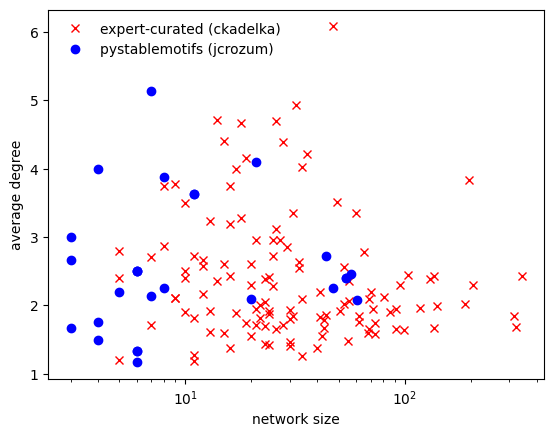

In [5]:
sizes_sm = [bn.N for bn in bns_sm]
average_degrees_sm = [np.mean(bn.indegrees) for bn in bns_sm]

f,ax = plt.subplots()
ax.semilogx(sizes,average_degrees,'rx',label = 'expert-curated (ckadelka)')
ax.semilogx(sizes_sm,average_degrees_sm,'bo',label = 'pystablemotifs (jcrozum)')
ax.set_xlabel('network size')
ax.set_ylabel('average degree')
ax.legend(loc='best',frameon=False);